In [106]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import scipy.stats
from typing import List, Tuple, Dict
from tqdm import tqdm

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [107]:
"""
Load SIS simulation event times output by the Java App into a NumPy array.

- Input directory: `output/sis`
  - `metadata.csv` for parameters (itr, batch_num, c_list, lambda range)
  - `times_XX.txt` where each line is a comma-separated list of event times

- Output array `time`: shape = (len(cList), len(lambdaList), itr), dtype=object
  Each element is a 1D NumPy array of float64 event times for a single run.

Usage:
    from scripts.load_sis_time import load_time_array
    time, axes = load_time_array(output_dir="output/sis", batch_idx=0)
    # time.shape -> (C, L, itr)
    # axes["c_list"], axes["lambda_list"], axes["itr"]
"""

from __future__ import annotations

output_path = os.path.abspath(os.path.join('..', 'output/sis/S1/z=6/N=10000finalintro'))
# output_path = os.path.abspath(os.path.join('..', 'java-project', 'output'))
if output_path not in sys.path:
    sys.path.append(output_path)

def _read_params(params_path: str) -> Dict[str, str]:
    params = pd.read_csv(params_path)
    network_type = params['networkType'].values[0]
    N = params['N'].values[0]
    k_ave = params['k_ave'].values[0]
    gamma = params['gamma'].values[0]
    rho0 = params['rho0'].values[0]
    tmax = params['tmax'].values[0]
    c_list = params['cList'].values[0]
    rewire_prob = params['rewireProb'].values[0]
    lambda_values = params['lambdaList'].values[0]
    seed = params['seed'].values[0]
    itr = params['itr'].values[0]
    batchNum = params['batchNum'].values[0]
    file_type = params['fileType'].values[0]

    if c_list and ":" in c_list:
        c_list = c_list.split(":")
        c_list = [float(c) for c in c_list]

    else:
        c_list = [float(c_list)]

    if rewire_prob and ":" in rewire_prob:
        rewire_prob = rewire_prob.split(":")
        rewire_prob = [float(rewire_prob_) for rewire_prob_ in rewire_prob]

    lamb_values = lambda_values.split(":")
    lamb_values = [float(lambda_) for lambda_ in lamb_values]

    return network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batchNum, file_type, c_list, lamb_values, rewire_prob


def _read_metadata(meta_path: str = os.path.join(output_path, "metadata.csv")) -> Dict[str, str]:
    """Read key,value style metadata where values may contain commas.

    This parser splits each line at the first comma only.
    Returns a dict of raw string values.
    """
    meta: Dict[str, str] = {}
    with open(meta_path, "r", encoding="utf-8") as f:
        # skip header if present
        header = f.readline()
        if "," not in header:
            # Unexpected; treat as data line
            key, val = header.strip().split(",", 1)
            meta[key.strip()] = val.strip()
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if "," not in line:
                continue
            key, val = line.split(",", 1)
            meta[key.strip()] = val.strip()
    return meta


def load_batch(output_dir: str, batch_idx: int, ) -> Tuple[np.ndarray, np.ndarray]:
    params_path = os.path.join(output_dir, "params.csv")
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"params.csv not found in {output_dir}")

    _, _, _, _, _, _, _, itr, _, file_type, c_list, lamb_values, rewire_prob = _read_params(params_path)

    P, C, L = len(rewire_prob), len(c_list), len(lamb_values)
    expected = P * C * L * itr

    times_file = os.path.join(output_dir, f"times_{batch_idx:02d}.txt")
    infected_file = os.path.join(output_dir, f"infected_num_{batch_idx:02d}.txt")
    if not os.path.exists(times_file) or not os.path.exists(infected_file):
        raise FileNotFoundError(f"Missing times or infected file for batch {batch_idx:02d}")

    time = np.empty((P, C, L, itr), dtype=object)
    infected = np.empty((P, C, L, itr), dtype=object)

    # Initialize with empty arrays to avoid uninitialized slots
    for p in range(P):
        for c in range(C):
            for l in range(L):
                for i in range(itr):
                    time[p, c, l, i] = np.array([], dtype=float)
                    infected[p, c, l, i] = np.array([], dtype=int)

    # Iterate paired lines; stop when either file ends
    tcount = icount = 0
    with open(times_file, "r", encoding="utf-8", errors="ignore") as tf, open(infected_file, "r", encoding="utf-8", errors="ignore") as inf:
        while True:
            tline = tf.readline()
            iline = inf.readline()
            if not tline or not iline:
                break
            ts = tline.strip()
            is_ = iline.strip()
            tarr = np.fromstring(ts, sep=",", dtype=float) if ts else np.array([], dtype=float)
            iarr = np.fromstring(is_, sep=",", dtype=int) if is_ else np.array([], dtype=int)

            flat_idx = tcount  # counts paired lines
            if flat_idx >= expected:
                break
            pIdx = flat_idx // (C * L * itr)
            rem = flat_idx % (C * L * itr)
            cIdx = rem // (L * itr)
            rem = rem % (L * itr)
            lIdx = rem // itr
            itIdx = rem % itr
            time[pIdx, cIdx, lIdx, itIdx] = tarr
            infected[pIdx, cIdx, lIdx, itIdx] = iarr
            tcount += 1
            icount += 1

    # If files contain additional lines beyond expected, ignore extras silently.
    # If fewer lines, warn but do not raise.
    if tcount < expected or icount < expected:
        missing = expected - min(tcount, icount)
        print(
            f"[WARN] Batch {batch_idx:02d}: filled {min(tcount, icount)} / {expected} runs; "
            f"{missing} missing. Unfilled slots remain empty arrays.")

    return time, infected

def load(path: str = output_path, max_file_num: int = 1e5) -> Tuple[np.ndarray, np.ndarray, Dict[str, object]]:
    network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batchNum, file_type, c_list, lamb_values, rewire_prob = _read_params(os.path.join(path, "params.csv"))

    valid_batch_idx = []
    valid_file_num = 0

    for batch_idx in range(batchNum):
        if os.path.exists(os.path.join(path, f"times_{batch_idx:02d}.txt")) and os.path.exists(os.path.join(path, f"infected_num_{batch_idx:02d}.txt")):
            # print(f"idx: {batch_idx}, {valid_file_num}th file is found")
            valid_batch_idx.append(batch_idx)
            valid_file_num += 1
            if valid_file_num >= max_file_num:
                break

    total_itr = len(valid_batch_idx) * itr
    shape = (len(rewire_prob), len(c_list), len(lamb_values), total_itr)
    times_all = np.zeros(shape, dtype=object)
    infected_num_all = np.zeros(shape, dtype=object)  # 修正: dtype=object

    # print("")
    print(f"Lets load {valid_file_num} files!")

    for batch_idx in tqdm(valid_batch_idx, desc="Loading files"):
        times, infected_num = load_batch(path, batch_idx)
        times_all[:, :, :, batch_idx * itr : (batch_idx + 1) * itr] = times
        infected_num_all[:, :, :, batch_idx * itr : (batch_idx + 1) * itr] = infected_num

    axes = {
        "network_type": network_type,
        "N": N,
        "k_ave": k_ave,
        "gamma": gamma,
        "rho0": rho0,
        "tmax": tmax,
        "seed": seed,
        "total_itr": total_itr,
        "file_type": file_type,
        "c_list": c_list,
        "lamb_values": lamb_values,
        "rewire_prob": rewire_prob,
    }

    return times_all, infected_num_all, axes

In [108]:
# y(Theta)を計算する関数
def y_SIS(deg_list, pk, lamb, gamma, Theta, c=0):
    # 平均次数 <k> = Σ k*p(k)
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -Theta

    y = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        y += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    
    y /= k_ave
    y -= Theta
    return y

# y'(Theta) = dy/dTheta を計算する関数
def dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c=0.0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -1.0
    dy = 0.0
    for k, p in zip(deg_list, pk):
        B = gamma + lamb * k * Theta * (1.0 + c * k * Theta)  # 正しい分母
        if B == 0:
            return np.nan
        fprime = (lamb * gamma * k * (1.0 + 2.0 * c * k * Theta)) / (B ** 2)
        dy += k * p * fprime
    dy /= k_ave
    dy -= 1.0
    return dy


# ニュートン法を実装した関数
def newton_method(deg_list, pk, lamb, gamma, Theta_initial=0.9, tolerance=1e-16, max_iter=100, c=0):
    """
    ニュートン法を用いて y_SIS(Theta) = 0 となるThetaを探す
    """
    Theta = Theta_initial
    for i in range(max_iter):
        y_val = y_SIS(deg_list, pk, lamb, gamma, Theta, c)
        
        # yが十分に0に近ければ終了
        if abs(y_val) < tolerance:
            return Theta

        dy_val = dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c)

        # 導関数が0に近く、更新が発散しそうな場合は終了
        if abs(dy_val) < 1e-10:
            # print(f"Warning: Derivative is too small at lambda={lamb}, Theta={Theta}. Stopping.")
            return Theta

        # ニュートン法の更新式
        Theta_new = Theta - y_val / dy_val
        
        # 更新量が十分に小さくなれば終了
        if abs(Theta_new - Theta) < tolerance:
            return Theta_new
            
        Theta = Theta_new
        
    # print(f"Warning: Newton's method did not converge for lambda={lamb} within {max_iter} iterations.")
    return Theta

def theta_to_I(deg_list, pk, lamb, gamma, Theta, c=0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return 0
    I = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        I += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    I /= k_ave
    return I

def theta_symbolic_RR_numeric(lamb: float, K: float, gamma: float, c: float) -> float:
    """
    RR（正則）ネットワークの閉形式解を用いて Theta(λ) を数値的に返す。
    - c=0 のとき: Theta = max(0, 1 - gamma/(lambda*K))
    - c>0 のとき: 2次方程式の正の根を使用。
    物理的制約に合わせて [0,1] にクリップする。
    """
    if lamb <= 0:
        return 0.0
    if c == 0:
        theta = 1.0 - gamma / (lamb * K)
        return float(np.clip(theta, 0.0, 1.0))
    a = c * K
    b = 1.0 - c * K
    c0 = gamma / (lamb * K) - 1.0
    D = b * b - 4.0 * a * c0
    if D < 0:
        return 0.0
    theta = (-b + np.sqrt(D)) / (2.0 * a)
    return float(np.clip(theta, 0.0, 1.0))

In [109]:
times_all, infected_num_all, axes = load()
meta = _read_metadata()
network_type = axes["network_type"]
N = axes["N"]
k_ave = axes["k_ave"]
gamma = axes["gamma"]
rho0 = axes["rho0"]
tmax = axes["tmax"]
seed = axes["seed"]
file_type = axes["file_type"]
total_itr = axes["total_itr"]
c_list = axes["c_list"]
lamb_values = axes["lamb_values"]
rewire_prob = axes["rewire_prob"]

Lets load 32 files!


Loading files: 100%|██████████| 32/32 [00:00<00:00, 114.64it/s]


In [110]:
print("==== shape ====")
print(times_all.shape)
print(infected_num_all.shape)

print("")
print("==== params ====")
print(f"network_type: {network_type}")
print(f"N: {N}")
print(f"k_ave: {k_ave}")
print(f"gamma: {gamma}")
print(f"rho0: {rho0}")
print(f"tmax: {tmax}")
print(f"seed: {seed}")
print(f"total_itr: {total_itr}")

print("")
print("==== meta data ====")
for key, value in meta.items():
    print(f"{key}: {value}")

==== shape ====
(2, 4, 51, 320)
(2, 4, 51, 320)

==== params ====
network_type: S1
N: 10000
k_ave: 6
gamma: 1.0
rho0: 1.0
tmax: 1000.0
seed: 0.0
total_itr: 320

==== meta data ====
start_time: 2025-09-14 03:50:33
end_time: 2025-09-14 03:56:07
duration_seconds: 334.080
network_type: S1
runs_per_batch: 2040
total_runs: 65280
seed_base: 0
os_name: Mac OS X
os_version: 15.6
java_version: 24.0.2
java_vendor: Homebrew
cpu_cores: 16
total_memory_mb: 3856
max_memory_mb: 12288


In [111]:
test_lamb_idx_list = [0, 10, 20, 50]

lamb_idx_list = []
for lamb_idx in test_lamb_idx_list:
    if lamb_idx < len(lamb_values):
        lamb_idx_list.append(lamb_idx)

lamb_idx_list = np.array(lamb_idx_list)


In [112]:
if file_type == "time":
    p_idx = 0
    fig, axes = plt.subplots(len(c_list), len(lamb_idx_list), figsize=(6 * len(lamb_idx_list), 6 * len(c_list)), squeeze=False)

    for c_idx, c in enumerate(c_list):
        for l_idx, lamb_idx in enumerate(lamb_idx_list):
            if len(c_list) == 1:
                ax = axes[0, l_idx]
            else:
                ax = axes[c_idx, l_idx]
            lamb = lamb_values[lamb_idx]
            event_nums = np.zeros(len(times_all[p_idx, c_idx, l_idx, :]))
            for itr_idx in range(len(times_all[p_idx, c_idx, l_idx, :])):
                event_nums[itr_idx] = len(times_all[p_idx, c_idx, l_idx, itr_idx])
            ax.hist(event_nums, bins=16, color=colors[0])
            ax.set_title(rf"$c={c}, \lambda={lamb:.4f}$")
            ax.set_xlabel("Number of events")
            ax.set_ylabel("frequency")

    fig.tight_layout()

    plt.show()

else:
    pass

In [113]:
if file_type == "time":

    fig, axes = plt.subplots(len(c_list), len(lamb_idx_list), figsize=(6 * len(lamb_idx_list), 6 * len(c_list)), sharey=True, squeeze=False)

    for c_idx, c in enumerate(c_list):
        for l_idx, lamb_idx in enumerate(lamb_idx_list):
            v_num = 0
            lamb = lamb_values[lamb_idx]
            if len(c_list) == 1:
                ax = axes[0, l_idx]
            else:
                ax = axes[c_idx, l_idx]
            for itr_idx in range(total_itr):
                I = infected_num_all[p_idx, c_idx, lamb_idx, itr_idx]
                t = times_all[p_idx, c_idx, lamb_idx, itr_idx]
                if len(t) > 0:
                    axes[c_idx, l_idx].plot(t, I, color=colors[0], alpha=0.5)

            ax.set_title(rf"$c={c}, \lambda={lamb:.4f}$")
            ax.set_xlabel("time")
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlim(1.0, tmax)
            if l_idx == 0:
                ax.set_ylabel(r"$I(t)$")

    fig.tight_layout()

    plt.show()
    
else:
    pass


In [114]:
plot_lamb_idx_lists = [[24, 25, 26, 27, 28, 29], [9, 10, 11, 12, 13, 14]]

if file_type == "time":

    fig, axes = plt.subplots(len(c_list), len(plot_lamb_idx_lists[0]), figsize=(6 * len(plot_lamb_idx_lists[0]), 6 * len(c_list)), sharey=True)

    for c_idx, c in enumerate(c_list):
        if c_idx == 0:
            plot_lamb_idx_list = plot_lamb_idx_lists[0]
        elif c_idx == 1:
            plot_lamb_idx_list = plot_lamb_idx_lists[1]
        else:
            raise ValueError(f"Invalid c_idx: {c_idx}")
        print(plot_lamb_idx_list)
        for l_idx, lamb_idx in enumerate(plot_lamb_idx_list):
            v_num = 0
            lamb = lamb_values[lamb_idx]
            for itr_idx in range(total_itr):
                I = infected_num_all[c_idx, lamb_idx, itr_idx]
                t = times_all[c_idx, lamb_idx, itr_idx]
                if len(t) > 0:
                    axes[c_idx, l_idx].plot(t, I, color=colors[0], alpha=0.5)

            axes[c_idx, l_idx].set_title(rf"$c={c}, \lambda={lamb:.4f}$")
            axes[c_idx, l_idx].set_xlabel("time")
            axes[c_idx, l_idx].set_xscale("log")
            axes[c_idx, l_idx].set_yscale("log")
            # axes[c_idx, l_idx].set_xlim(0, 10.0)
            if l_idx == 0:
                axes[c_idx, l_idx].set_ylabel(r"$I(t)$")

    fig.tight_layout()

    plt.show()
    
else:
    pass


In [115]:
threshold = -1
time = 1000
time_idx = np.zeros((len(rewire_prob), len(c_list), len(lamb_values), total_itr), dtype=int)

if file_type == "time":
    
    for p_idx in range(len(rewire_prob)):
        for c_idx in range(len(c_list)):
            print(f"c: {c_idx + 1} / {len(c_list)}")
            for l_idx in range(len(lamb_values)):
                is_print_lambda = l_idx % 10 == 0
                if is_print_lambda:
                    print(f" -->l: {l_idx} / {len(lamb_values)}")
                for itr_idx in range(total_itr):
                    last_time = times_all[p_idx, c_idx, l_idx, itr_idx][-1]
                    if last_time > time:
                        time_idx[p_idx, c_idx, l_idx, itr_idx] = int(np.where(times_all[p_idx, c_idx, l_idx, itr_idx] <= time)[0][-1])
                    else:
                        time_idx[p_idx, c_idx, l_idx, itr_idx] = -1


I_at_time = np.zeros((len(rewire_prob), len(c_list), len(lamb_values), total_itr))
valid_I_at_time = np.zeros((len(rewire_prob), len(c_list), len(lamb_values)))
valid_num = np.zeros((len(rewire_prob), len(c_list), len(lamb_values)))
for p_idx in range(len(rewire_prob)):
    for c_idx in range(len(c_list)):
        for lamb_idx in range(len(lamb_values)):
            valid = []
            non_valid = []
            for itr_idx in range(len(infected_num_all[p_idx, c_idx, lamb_idx])):
                I_at_time[p_idx, c_idx, lamb_idx, itr_idx] = infected_num_all[p_idx, c_idx, lamb_idx, itr_idx][time_idx[p_idx, c_idx, lamb_idx, itr_idx]]
            if I_at_time[p_idx, c_idx, lamb_idx, itr_idx] > threshold:
                valid.append(I_at_time[p_idx, c_idx, lamb_idx, itr_idx])
                valid_num[p_idx, c_idx, lamb_idx] += 1
            else:
                non_valid.append(I_at_time[p_idx, c_idx, lamb_idx, itr_idx])
        if len(valid) > 0:
            valid_I_at_time[p_idx, c_idx, lamb_idx] = np.mean(valid)
        else:
            valid_I_at_time[p_idx, c_idx, lamb_idx] = np.mean(non_valid)


In [116]:
# fig, axes = plt.subplots(len(c_list), len(lamb_idx_list), figsize=(6 * len(lamb_idx_list), 6 * len(c_list)), squeeze=False)
# # fig, axes = plt.subplots(len(c_list), len(lamb_idx_list), figsize=(6 * len(lamb_idx_list), 6 * len(c_list)))

# for c_idx, c in enumerate(c_list):
#     for l_idx, lamb_idx in enumerate(lamb_idx_list):
#         if len(c_list) == 1:
#             ax = axes[0, l_idx]
#         else:
#             ax = axes[c_idx, l_idx]
#         lamb = lamb_values[lamb_idx]
#         ax.hist(I_at_time[c_idx, lamb_idx, :]/N, bins=16)
#         ax.set_title(rf"$c={c}, \lambda={lamb:.4f}$")
#         ax.set_xlabel(rf"$I({tmax})$")
#         ax.set_ylabel("frequency")

# fig.tight_layout()

# plt.show()

In [117]:
# # lamb_values_for_theory = lamb_values
# lamb_values_for_theory = np.linspace(np.min(lamb_values), np.max(lamb_values), 1000)
# theta_all = np.zeros((len(c_list), len(lamb_values_for_theory)))
# I_theory = np.zeros((len(c_list), len(lamb_values_for_theory)))

# for cidx, c in enumerate(c_list):
#     theta_results = []

#     # 各lambdaについてニュートン法でThetaを解く
#     for lamb_idx, lamb in enumerate(lamb_values_for_theory):
#         if network_type == "RR":
#             # 次数のリスト
#             deg_list = [k_ave]
#             pk = np.array([1.0])
#             solution = theta_symbolic_RR_numeric(lamb, k_ave, gamma, c)

#         elif network_type == "ER":
#             # 次数のリスト (ポアソン分布が意味を持つ範囲)
#             # 平均の3倍+10程度あれば十分
#             deg_list = np.arange(0, int(k_ave * 3) + 10)

#             # 次数分布 p(k) を計算 (ポアソン分布)
#             pk = scipy.stats.poisson.pmf(deg_list, k_ave)
#             solution = newton_method(deg_list, pk, lamb, gamma, c=c)

#         # elif network_type == "SF":
#         #     deg_list = np.arange(1, 1000)

#         #     C = (2 - kappa) * k_ave
#         #     pk = C * deg_list ** (- kappa)

#         else:
#             raise ValueError(f"Invalid network type: {network_type}")

#         # 初期値は重要。ここでは前のステップの結果を流用すると収束しやすいが、簡単のため固定値から始める
#         # 問題によってはTheta=0も根になる（自明な解）ため、0以外の初期値を選ぶ
#         # 物理的に意味のある解は [0,1] に収める
#         solution = float(np.clip(solution, 0.0, 1.0))
#         # print(f"{lamb:.4f}, {solution:.8f}")
#         I_theory[cidx, lamb_idx] = theta_to_I(deg_list, pk, lamb, gamma, solution, c=c)

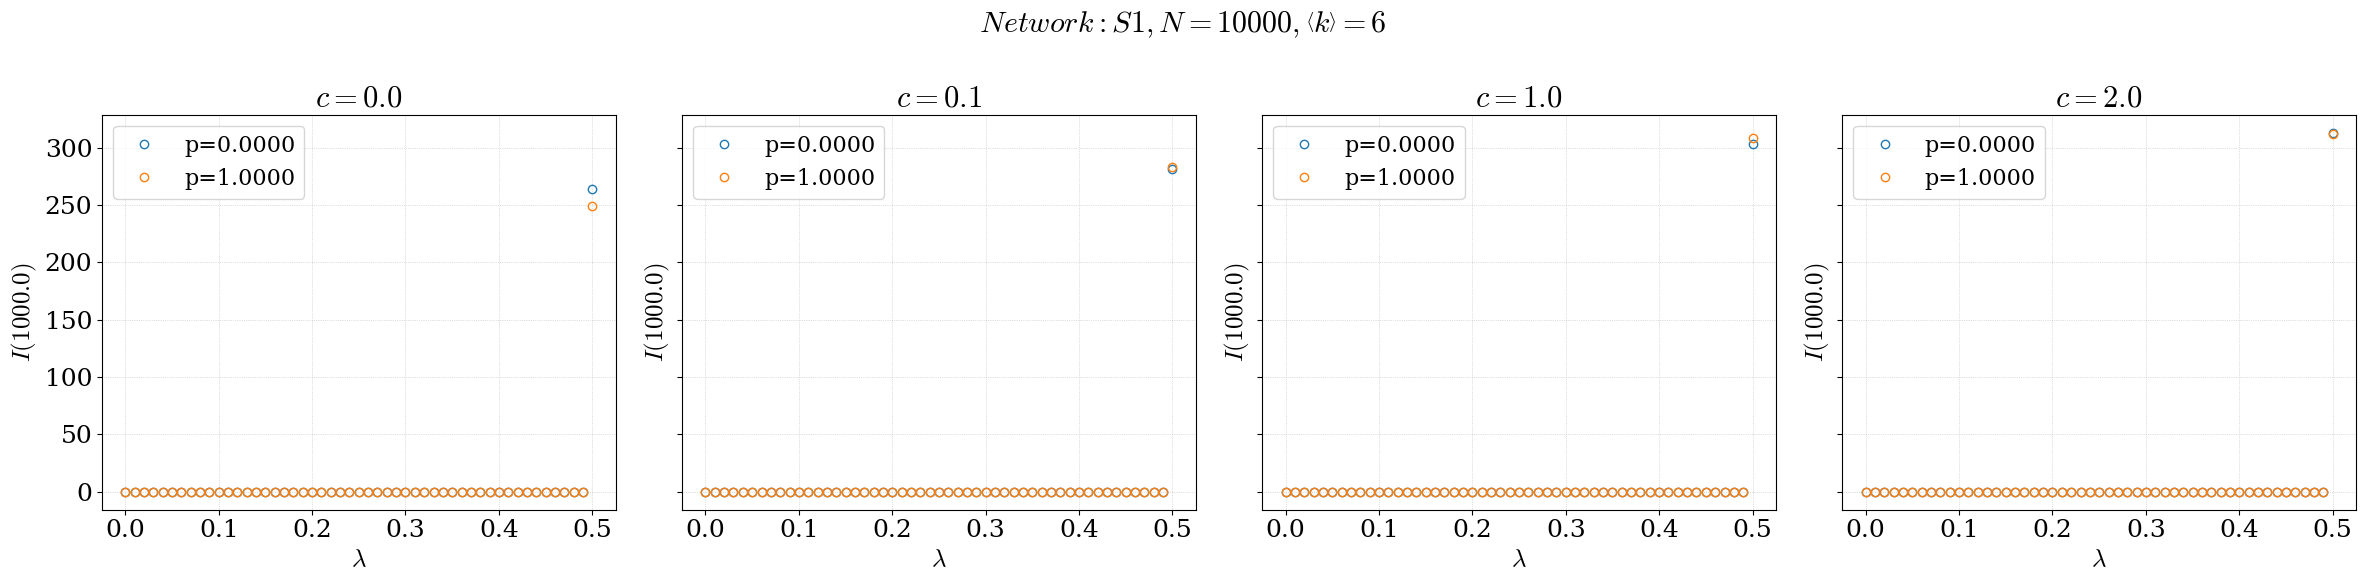

In [118]:
fig, axes = plt.subplots(1, len(c_list), figsize=(6 * len(c_list), 6), sharey=True)

for c_idx, c in enumerate(c_list):
    if len(c_list) == 1:
        ax = axes
    else:
        ax = axes[c_idx]
    # ax.plot(lamb_values_for_theory, I_theory[c_idx, :], label="Theory", linestyle="--", linewidth=0.5)
    for p_idx, p, in enumerate(rewire_prob):
        ax.plot(lamb_values, valid_I_at_time[p_idx, c_idx, :], label=f"p={p:.4f}", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[p_idx])
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_title(rf"$c={c}$")
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(rf"$I({tmax})$")

fig.suptitle(rf"$Network: {network_type}, N={N}, \left<k\right>={k_ave}$")
fig.tight_layout()

plt.show()

In [119]:
alive_sample_num = np.zeros((len(c_list), len(lamb_values)))
for c_idx in range(len(c_list)):
    for lamb_idx in range(len(lamb_values)):
        for itr_idx in range(total_itr):
            if infected_num_all[c_idx, lamb_idx, itr_idx] > 0:
                alive_sample_num[c_idx, lamb_idx] += 1

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

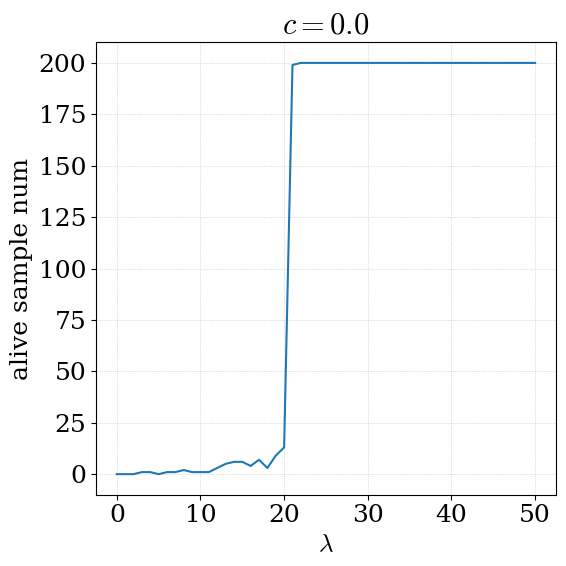

In [ ]:
fig, axes = plt.subplots(1, len(c_list), figsize=(6 * len(c_list), 6))
for c_idx, c in enumerate(c_list):
    if len(c_list) == 1:
        ax = axes
    else:
        ax = axes[c_idx]
    ax.plot(alive_sample_num[c_idx, :])
    ax.set_title(rf"$c={c}$")
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel("alive sample num")
    ax.grid(True, linestyle=":", alpha=0.5)

fig.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (3,) and (4, 3)

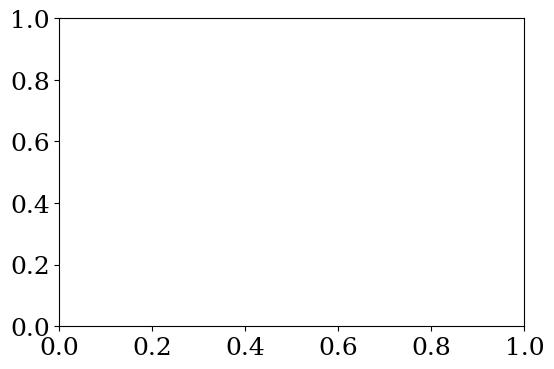

In [ ]:
fig = plt.figure(figsize=(6, 4))

# plt.plot(lamb_values_for_theory, I_theory[0, :], label="Theory", linestyle="--", linewidth=0.5)
plt.plot(lamb_values, valid_I_at_time[0, :]/N, linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[0])
plt.grid(True, linestyle=":", alpha=0.5)
# plt.title(rf"$c={c}$")
plt.xlabel(r"$\lambda$")
plt.ylabel(rf"$I({tmax})$")

# fig.suptitle(rf"$Network: {network_type}, N={N}, \left<k\right>={k_ave}$")
fig.tight_layout()

plt.show()

In [ ]:
output_path = os.path.abspath(os.path.join('..', 'output/sis/RR/z=6/N=10000finalintro'))
times_all2, infected_num_all2, axes2 = load(path=output_path, max_file_num=3)
meta2 = _read_metadata()
network_type2 = axes2["network_type"]
N2 = axes2["N"]
k_ave2 = axes2["k_ave"]
gamma2 = axes2["gamma"]
rho02 = axes2["rho0"]
tmax2 = axes2["tmax"]
seed2 = axes2["seed"]
file_type2 = axes2["file_type"]
total_itr2 = axes2["total_itr"]
c_list2 = axes2["c_list"]
lamb_values2 = axes2["lamb_values"]

Lets load 3 files!


Loading files: 100%|██████████| 3/3 [01:03<00:00, 21.01s/it]


In [ ]:
print("==== shape ====")
print(times_all2.shape)
print(infected_num_all2.shape)

print("")
print("==== params ====")
print(f"network_type: {network_type2}")
print(f"N: {N2}")
print(f"k_ave: {k_ave2}")
print(f"gamma: {gamma2}")
print(f"rho0: {rho02}")
print(f"tmax: {tmax2}")
print(f"seed: {seed2}")
print(f"total_itr: {total_itr2}")

print("")
print("==== meta data ====")
for key, value in meta2.items():
    print(f"{key}: {value}")

==== shape ====
(1, 3, 60)
(1, 3, 60)

==== params ====
network_type: RR
N: 10000
k_ave: 6
gamma: 1.0
rho0: 1.0
tmax: 1000.0
seed: 0.0
total_itr: 60

==== meta data ====
start_time: 2025-09-13 04:12:39
end_time: 2025-09-13 04:39:24
duration_seconds: 1604.466
network_type: RR
runs_per_batch: 1020
total_runs: 10200
seed_base: 0
os_name: Mac OS X
os_version: 15.6
java_version: 24.0.2
java_vendor: Homebrew
cpu_cores: 16
total_memory_mb: 12288
max_memory_mb: 12288


In [ ]:
# lamb_idx_list2 = np.array([i for i in range(len(lamb_values2))])
# fig, axes = plt.subplots(len(c_list), len(lamb_idx_list2), figsize=(6 * len(lamb_idx_list2), 6 * len(c_list)), sharey=True, squeeze=False)

# for c_idx, c in enumerate(c_list2):
#     for l_idx, lamb_idx in enumerate(lamb_idx_list2):
#         v_num = 0
#         lamb = lamb_values2[lamb_idx]
#         if len(c_list2) == 1:
#             ax = axes[0, l_idx]
#         else:
#             ax = axes[c_idx, l_idx]
#         for itr_idx in range(total_itr2):
#             I = infected_num_all2[c_idx, lamb_idx, itr_idx]
#             t = times_all2[c_idx, lamb_idx, itr_idx]
#             if len(t) > 0:
#                 axes[c_idx, l_idx].plot(t, I, color=colors[0], alpha=0.2)

#         ax.set_title(rf"$c={c}, \lambda={lamb:.4f}$")
#         ax.set_xlabel("time")
#         ax.set_xscale("log")
#         ax.set_yscale("log")
#         ax.set_xlim(1.0, tmax)
#         if l_idx == 0:
#             ax.set_ylabel(r"$I(t)$")

# fig.tight_layout()

# plt.show()


In [ ]:
c_list

[0.0]

/var/folders/vv/tq6tx6p94wqgdfkf0hhvjs8c0000gn/T/ipykernel_93802/1879765904.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/var/folders/vv/tq6tx6p94wqgdfkf0hhvjs8c0000gn/T/ipykernel_93802/1879765904.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/Users/black/.pyenv/versions/3.12.3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


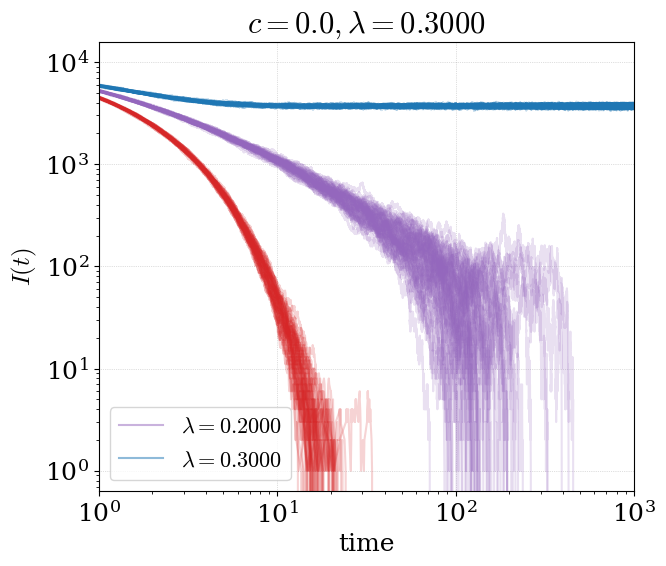

In [ ]:
colors = ["tab:red", "tab:purple", "tab:blue"]
lamb_idx_list2 = np.array([i for i in range(len(lamb_values2))])
fig, axes = plt.subplots(len(c_list), 1, figsize=(7, 6 * len(c_list)), sharey=True, squeeze=False)

for c_idx, c in enumerate(c_list2):
    for l_idx, lamb_idx in enumerate(lamb_idx_list2):
        v_num = 0
        lamb = lamb_values2[lamb_idx]
        label = rf"$\lambda={lamb:.4f}$"
        ax.plot([], [], color=colors[lamb_idx], label=label, alpha=0.5)
        if len(c_list2) == 1:
            ax = axes[0, 0]
        else:
            ax = axes[c_idx, 0]
        for itr_idx in range(total_itr2):
            I = infected_num_all2[c_idx, lamb_idx, itr_idx]
            t = times_all2[c_idx, lamb_idx, itr_idx]
            if len(t) > 0:
                axes[c_idx, 0].plot(t, I, color=colors[lamb_idx], alpha=0.2)

        ax.set_title(rf"$c={c}, \lambda={lamb:.4f}$")
        ax.set_xlabel("time")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(1.0, tmax)
        if l_idx == 0:
            ax.set_ylabel(r"$I(t)$")

        ax.grid(True, linestyle=":", alpha=0.5)
        ax.legend()
fig.tight_layout()

plt.show()


/var/folders/vv/tq6tx6p94wqgdfkf0hhvjs8c0000gn/T/ipykernel_93802/4123098927.py:44: RuntimeWarning: Mean of empty slice
  mean_I = np.nanmean(I_interp, axis=0)
/Users/black/.pyenv/versions/3.12.3/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


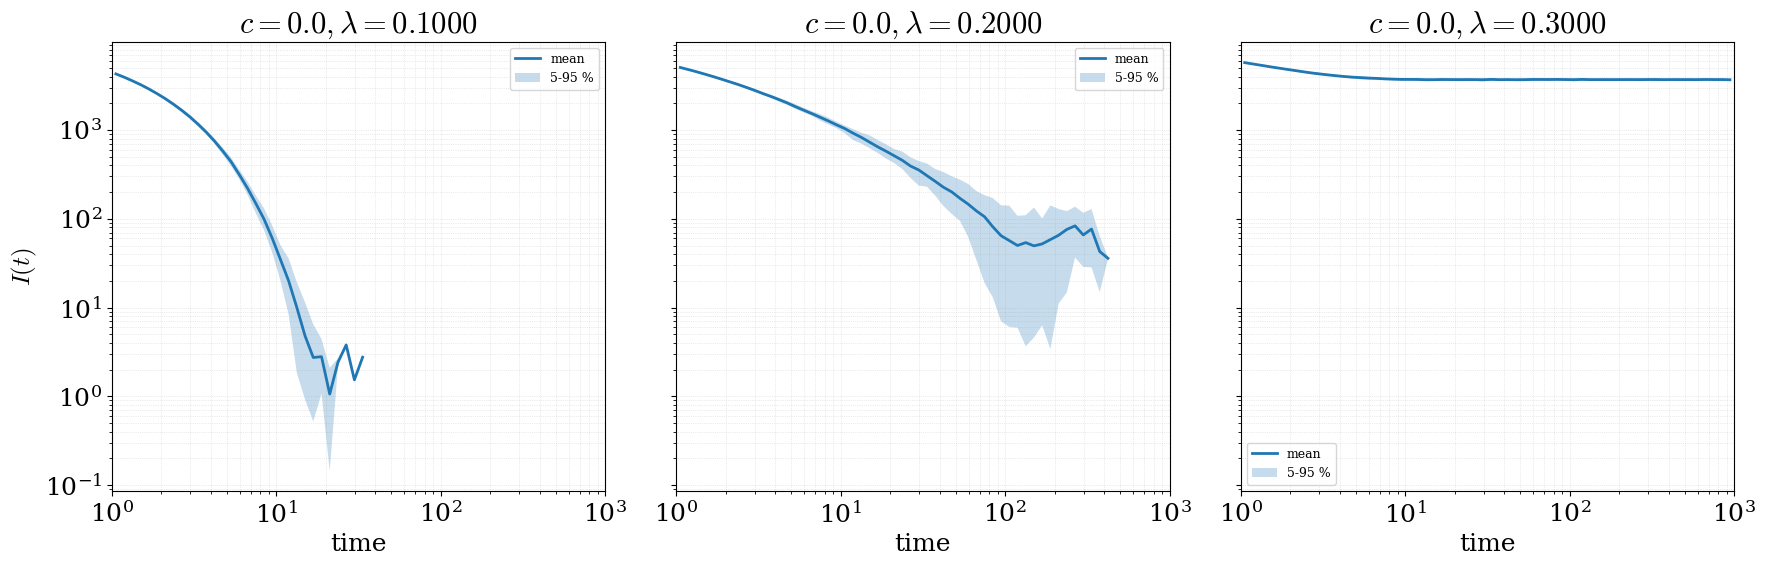

In [ ]:
# パラメータ（お好みで調整）
nbins = 60             # 時間ビン数（log 等間隔）
tmin  = 1.0            # xlim の下限に合わせる
tmax_ = tmax           # 既存の tmax を使用
ci_lo, ci_hi = 5, 95   # 信頼帯（5–95%）

# log 等間隔のビンとビン中心（幾何平均）
t_edges   = np.logspace(np.log10(tmin), np.log10(tmax_), nbins + 1)
t_centers = np.sqrt(t_edges[:-1] * t_edges[1:])

lamb_idx_list2 = np.array([i for i in range(len(lamb_values2))])
fig, axes = plt.subplots(len(c_list2), len(lamb_idx_list2),
                         figsize=(6 * len(lamb_idx_list2), 6 * len(c_list2)),
                         sharey=True, squeeze=False)

for c_idx, c in enumerate(c_list2):
    for l_idx, lamb_idx in enumerate(lamb_idx_list2):
        lamb = lamb_values2[lamb_idx]
        ax = axes[c_idx, l_idx] if len(c_list2) > 1 else axes[0, l_idx]

        # すべての試行をビン中心に補間して (n_iter, nbins) 配列に積む
        I_interp_list = []
        for itr_idx in range(total_itr2):
            I = infected_num_all2[c_idx, lamb_idx, itr_idx]  # 形状: (Ti,)
            t = times_all2[c_idx, lamb_idx, itr_idx]         # 形状: (Ti,)
            if len(t) == 0:
                continue
            # 時間が単調でない可能性に備えソート
            order = np.argsort(t)
            t_sorted = np.asarray(t)[order]
            I_sorted = np.asarray(I)[order]

            # 範囲外は NaN に（系列が終わった後は欠損として扱う）
            Ii = np.interp(t_centers, t_sorted, I_sorted,
                           left=np.nan, right=np.nan)
            I_interp_list.append(Ii)

        if len(I_interp_list) == 0:
            continue

        I_interp = np.vstack(I_interp_list)  # (n_iter, nbins)

        # ビンごとの統計量（NaN 無視）
        mean_I = np.nanmean(I_interp, axis=0)
        lo_I   = np.nanpercentile(I_interp, ci_lo, axis=0)
        hi_I   = np.nanpercentile(I_interp, ci_hi, axis=0)

        # 描画：平均＋信頼帯
        ax.plot(t_centers, mean_I, linewidth=2, label="mean")
        ax.fill_between(t_centers, lo_I, hi_I, alpha=0.25, label=f"{ci_lo}-{ci_hi} %")

        # （オプション）点が多いなら間引いてエラーバー表示もできる
        # step = max(1, nbins // 20)
        # ax.errorbar(t_centers[::step], mean_I[::step],
        #             yerr=[mean_I[::step] - lo_I[::step], hi_I[::step] - mean_I[::step]],
        #             fmt='o', ms=3, lw=1, capsize=3, alpha=0.8)

        ax.set_title(rf"$c={c}, \lambda={lamb:.4f}$")
        ax.set_xlabel("time")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(tmin, tmax_)
        if l_idx == 0:
            ax.set_ylabel(r"$I(t)$")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="best", fontsize=9)

fig.tight_layout()
plt.show()
